## 1) Setup

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

## 2) Simulate many dice experiments

We will:

* roll a die 20 times
* repeat the experiment 5000 times

In [2]:
def roll_die():
    return random.randint(1,6)

experiments = []

for _ in range(5000):              # repeat experiment many times
    rolls = []
    for _ in range(20):            # 20 rolls each experiment
        rolls.append(roll_die())
    experiments.append(rolls)

Convert to dataframe:

In [3]:
df = pd.DataFrame(experiments)

Each row = one experiment  
Each column = one roll

In [4]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,6,1,1,6,3,2,2,2,6,1,6,6,5,1,5,4,1,1,1,2
1,2,5,5,1,5,2,6,6,6,5,4,2,4,5,3,1,2,6,4,3
2,3,2,2,3,1,1,4,1,3,3,5,3,1,6,4,5,1,4,1,5
3,3,6,5,3,5,2,6,1,1,6,2,3,1,2,1,4,3,4,6,3
4,2,3,3,2,6,3,6,6,6,1,5,6,2,5,6,2,2,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,5,4,1,2,3,5,2,1,1,5,6,3,6,2,3,6,6,5,4
4996,2,1,5,5,1,4,3,4,2,4,2,5,1,1,4,6,3,5,3,3
4997,4,2,2,6,3,3,3,6,1,6,3,2,4,1,4,3,4,5,1,3
4998,3,6,1,5,5,3,6,2,1,4,6,4,2,6,5,4,2,2,5,2


## 3) BINOMIAL WORLD — count sixes

We count how many times "6" appears in each experiment.

In [7]:
df["num_sixes"] = (df == 6).sum(axis=1)

df["num_sixes"]

0       5
1       4
2       1
3       4
4       7
       ..
4995    4
4996    1
4997    3
4998    4
4999    4
Name: num_sixes, Length: 5000, dtype: int64

In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,num_sixes
0,6,1,1,6,3,2,2,2,6,1,...,6,5,1,5,4,1,1,1,2,5
1,2,5,5,1,5,2,6,6,6,5,...,2,4,5,3,1,2,6,4,3,4
2,3,2,2,3,1,1,4,1,3,3,...,3,1,6,4,5,1,4,1,5,1
3,3,6,5,3,5,2,6,1,1,6,...,3,1,2,1,4,3,4,6,3,4
4,2,3,3,2,6,3,6,6,6,1,...,6,2,5,6,2,2,4,4,3,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,5,4,1,2,3,5,2,1,1,...,6,3,6,2,3,6,6,5,4,4
4996,2,1,5,5,1,4,3,4,2,4,...,5,1,1,4,6,3,5,3,3,1
4997,4,2,2,6,3,3,3,6,1,6,...,2,4,1,4,3,4,5,1,3,3
4998,3,6,1,5,5,3,6,2,1,4,...,4,2,6,5,4,2,2,5,2,4


Plot:

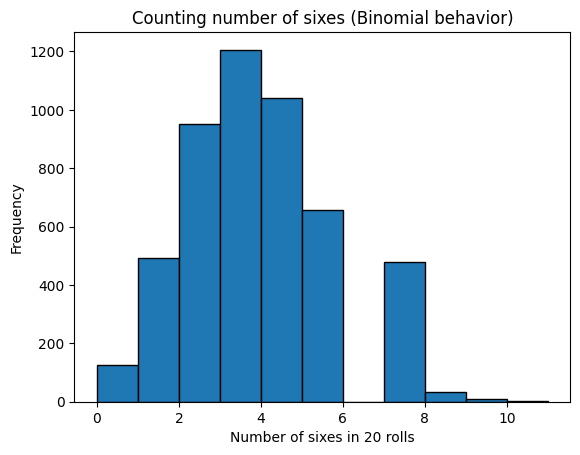

In [10]:
plt.hist(df["num_sixes"], bins=range(0,12), edgecolor="black")
plt.title("Counting number of sixes (Binomial behavior)")
plt.xlabel("Number of sixes in 20 rolls")
plt.ylabel("Frequency")
plt.show()

You should see **spiky bars**.

You care about exact counts:

> 2 sixes vs 3 sixes matters a lot

## 4) LESS DISCRETE — count evens

Now success = even number (2,4,6)

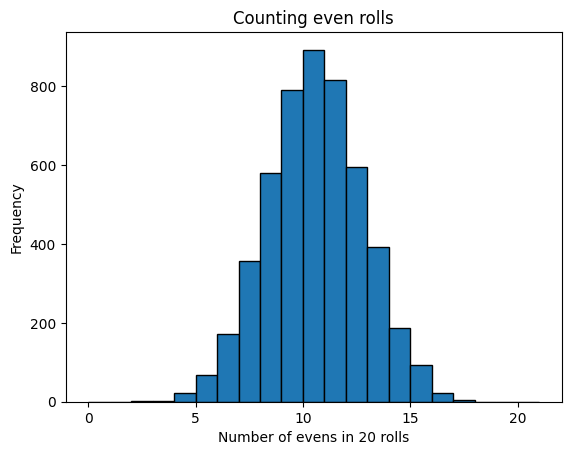

In [13]:
roll_cols = df.columns[:20]

df["num_evens"] = (df[roll_cols] % 2 == 0).sum(axis=1)

plt.hist(df["num_evens"], bins=range(0,22), edgecolor="black")
plt.title("Counting even rolls")
plt.xlabel("Number of evens in 20 rolls")
plt.ylabel("Frequency")
plt.show()

Now the shape looks like a **hill**

Still counts… but smoother.

## 5) NORMAL WORLD — average roll

Now instead of counting events, we measure the average value.

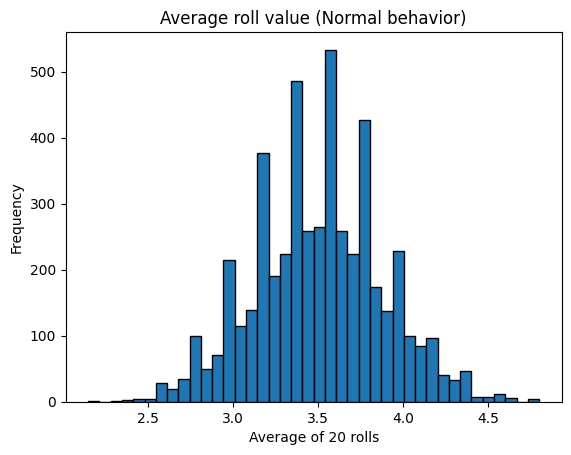

In [14]:
df["avg_roll"] = df[roll_cols].mean(axis=1)

plt.hist(df["avg_roll"], bins=40, edgecolor="black")
plt.title("Average roll value (Normal behavior)")
plt.xlabel("Average of 20 rolls")
plt.ylabel("Frequency")
plt.show()

Now you should see a **smoother bell curve**

Same dice  
Same randomness  
Different question

## 6) Key Comparison

Print summary:

In [15]:
print("Average of averages:", df["avg_roll"].mean())
print("Spread of averages:", df["avg_roll"].std())

Average of averages: 3.50576
Spread of averages: 0.37790658247378467


You'll notice:  
The averages cluster tightly around ~3.5

## What you just demonstrated

You did NOT change randomness.

You changed what you measured:

| Measurement  | Behavior          |
| ------------ | ----------------- |
| count sixes  | binomial          |
| count evens  | binomial-ish hill |
| average roll | normal            |

## If you want a nice extension

Increase number of rolls to 100:

```python
# change 20 → 100 above and rerun
```

The bell curve becomes tighter.

That is the entire foundation of statistics.

---

## Poisson — random arrivals in time

Now we simulate a different kind of randomness using the same dice.

Instead of a fixed number of rolls, rolls happen randomly over time:

> "How many sixes happen in 1 minute of random rolling?"

We don't pre-decide the number of rolls.  
Rolls arrive randomly, and that's the key difference from binomial.

## Idea of the simulation

Real life:

* You roll continuously
* Sometimes quickly, sometimes slower
* Each moment has a small chance a roll happens
* Each roll has a chance to be a 6

We will simulate time passing in tiny steps.

Every tiny moment:

1. maybe a roll happens
2. if a roll happens → maybe it is a 6

This produces **random arrivals**, which is exactly Poisson behavior.

## 2) Simulate one minute

Instead of looping through tiny time slices, we can simulate this more directly:

1. Draw the number of rolls from a Poisson distribution (average ~120 rolls per minute)
2. Roll the die that many times and count sixes

This captures the same idea — the number of opportunities is itself random.

In [16]:
import numpy as np

def simulate_one_minute():
    num_rolls = np.random.poisson(lam=120)  # random number of rolls in a minute
    rolls = [random.randint(1,6) for _ in range(num_rolls)]
    return rolls.count(6)


## 3) Repeat the experiment many times

We simulate many different minutes.

In [17]:
results = []

for _ in range(5000):
    results.append(simulate_one_minute())

df = pd.DataFrame({"sixes_per_minute": results})
df.head()

,sixes_per_minute
0,30
1,16
2,14
3,25
4,23


In [18]:
df

,sixes_per_minute
0,30
1,16
2,14
3,25
4,23
...,...
4995,21
4996,22
4997,24
4998,22


## 4) Plot the distribution

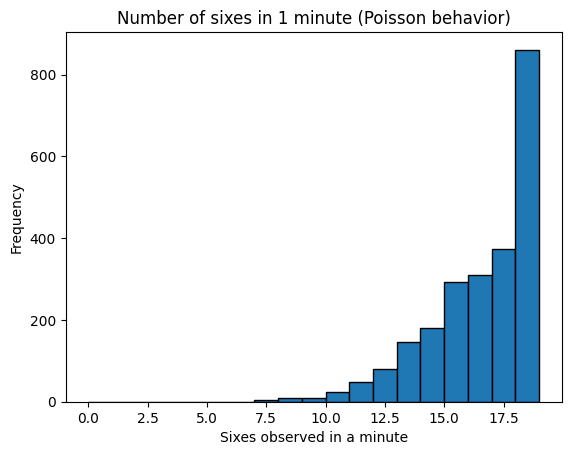

In [20]:
plt.hist(df["sixes_per_minute"], bins=range(0,20), edgecolor="black")
plt.title("Number of sixes in 1 minute (Poisson behavior)")
plt.xlabel("Sixes observed in a minute")
plt.ylabel("Frequency")
plt.show()

You should see:

* many small values
* few large values
* skewed right
* not symmetric

That's Poisson.

## 5) Compare to binomial (fixed rolls)

Now contrast it with a fixed number of rolls (old world).

Exactly 120 rolls every time:

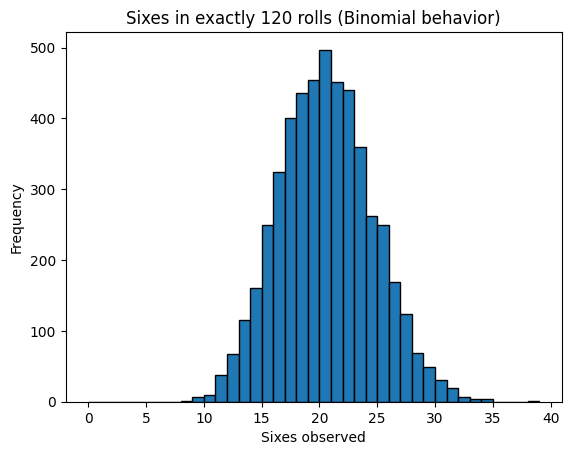

In [21]:
def fixed_rolls():
    count = 0
    for _ in range(120):
        if random.randint(1,6) == 6:
            count += 1
    return count

binomial_results = [fixed_rolls() for _ in range(5000)]

plt.hist(binomial_results, bins=range(0,40), edgecolor="black")
plt.title("Sixes in exactly 120 rolls (Binomial behavior)")
plt.xlabel("Sixes observed")
plt.ylabel("Frequency")
plt.show()

This one becomes more bell-shaped.

## What you just observed

| Situation               | Distribution |
| ----------------------- | ------------ |
| fixed number of rolls   | binomial     |
| random arrivals in time | poisson      |

Same dice  
Same probability  
Different structure of randomness

## The intuition

Poisson appears when:

> events occur randomly over time without a fixed number of attempts

You didn't count trials — you counted arrivals.

## One-sentence memory trick

**Binomial** = "Out of how many tries?"  
**Poisson** = "During how long?"

---

## Negative Binomial — count attempts to reach a goal

You now have two mental models:

* **Binomial** → fixed number of rolls → count successes
* **Poisson** → fixed time → count arrivals

The negative binomial flips the question:

> **Fixed number of successes → count how many attempts it takes**

It's not time-based and not trial-based. It's **goal-based** — you stop when you reach a target.

## Stay in the same dice universe 🎲

We keep:

> success = rolling a 6

But now the rule changes:

Instead of rolling 20 times  
or rolling for 1 minute

You say:

> "I will keep rolling until I get 5 sixes."

You don't know how many rolls it will take.

Sometimes lucky:

```
6,2,6,6,3,1,6,4,6   → only 9 rolls
```

Sometimes unlucky:

```
2,3,4,1,5,2,3,1,4,2,5,1,3,4,2,5,6,... → maybe 40 rolls
```

You record:

> number of rolls required to reach 5 successes

Repeat experiment many times.

You'll see:

```
8, 14, 21, 9, 17, 35, 12, 18, 10...
```

Plot that → right-skewed shape.

That is the **negative binomial distribution**

## Intuition

Instead of asking:

> How many successes happen?

You ask:

> How much effort until success?

This appears everywhere in real life:

* number of customers contacted before making 3 sales
* number of experiments before 2 successful results
* number of shots before scoring 1 goal

You stop when goal achieved.

## Comparison (important)

| Distribution      | What is fixed | What varies       |
| ----------------- | ------------- | ----------------- |
| Binomial          | attempts      | successes         |
| Poisson           | time          | arrivals          |
| Negative Binomial | successes     | attempts required |

This is the cleanest way to remember it.

## Now let's simulate it in Python

### 2) Function: rolls needed to get 5 sixes

In [22]:
def rolls_until_5_sixes():
    sixes = 0
    rolls = 0
    
    while sixes < 5:
        rolls += 1
        if random.randint(1,6) == 6:
            sixes += 1
            
    return rolls

### 3) Repeat many experiments

In [23]:
results = []

for _ in range(5000):
    results.append(rolls_until_5_sixes())

df = pd.DataFrame({"rolls_needed": results})
df.head()

,rolls_needed
0,24
1,36
2,31
3,47
4,20


### 4) Plot distribution

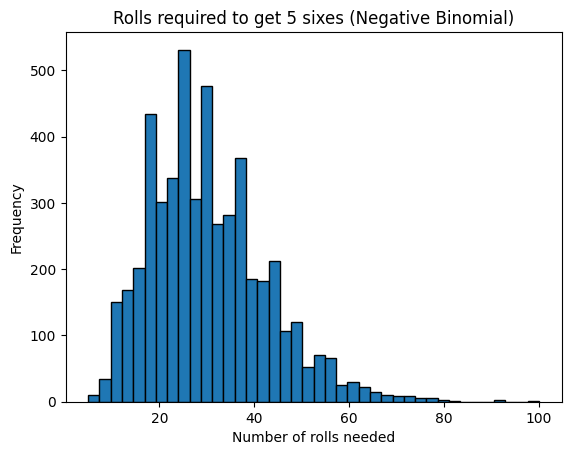

In [24]:
plt.hist(df["rolls_needed"], bins=40, edgecolor="black")
plt.title("Rolls required to get 5 sixes (Negative Binomial)")
plt.xlabel("Number of rolls needed")
plt.ylabel("Frequency")
plt.show()

You will see:

* cannot be small (minimum = 5)
* long right tail
* skewed distribution

## Why it's called *negative* binomial

Because it is basically the reverse question of binomial:

Binomial:

> successes after fixed rolls

Negative binomial:

> rolls after fixed successes

They are mathematical inverses.

## One-sentence intuition

Binomial counts wins in fixed effort.  
Negative binomial measures effort to reach fixed wins.

## Final mental map

Think of a video game:

| Question                                     | Distribution      |
| -------------------------------------------- | ----------------- |
| How many enemies defeated in 30 attacks?     | Binomial          |
| How many enemies appear in 1 minute?         | Poisson           |
| How many attacks until defeating 10 enemies? | Negative Binomial |

## Geometric Distribution

Geometric is the simplest member of this family.

Negative binomial asks: "How many rolls until I get 5 sixes?"

Now shrink the goal to just one.

## Geometric Distribution (same dice world 🎲)

Keep everything identical:

> success = rolling a 6

But now the rule:

> "Keep rolling until the FIRST six appears."

That's it.

You stop immediately when success happens.

## Run a few experiments mentally

```
6 → took 1 roll
3,6 → took 2 rolls
2,5,1,4,3,6 → took 6 rolls
1,2,3,4,5,1,2,3,4,5,6 → took 11 rolls
```

Record only:

> number of rolls needed to get first six

Repeat many times:

```
1, 2, 4, 1, 7, 3, 12, 2, 1, 5, 3, 20, 6...
```

Plot → sharply right-skewed

That's the **geometric distribution**

## What makes it special?

You don't care about multiple successes.

You only care about:

> waiting time until the first success

It's the most basic "waiting" randomness.

## Relationship to negative binomial

Negative binomial:

> rolls until 5 successes

Geometric:

> rolls until 1 success

So:

> geometric = negative binomial with goal = 1

## Intuition

Geometric models **patience**.

Examples:

* how many calls until first sale
* how many attempts until first bug found
* how many shots until first goal
* how many swipes until first match 😄

You don't fix effort or time.  
You wait until something finally works.

## Python simulation

### 2) Function: rolls until first six

In [16]:
def rolls_until_first_six():
    rolls = 0
    
    while True:
        rolls += 1
        if random.randint(1,6) == 6:
            return rolls

### 3) Repeat experiment many times

In [17]:
results = []

for _ in range(5000):
    results.append(rolls_until_first_six())

df = pd.DataFrame({"rolls_needed": results})
df.head()

,rolls_needed
0,4
1,1
2,37
3,23
4,1


### 4) Plot distribution

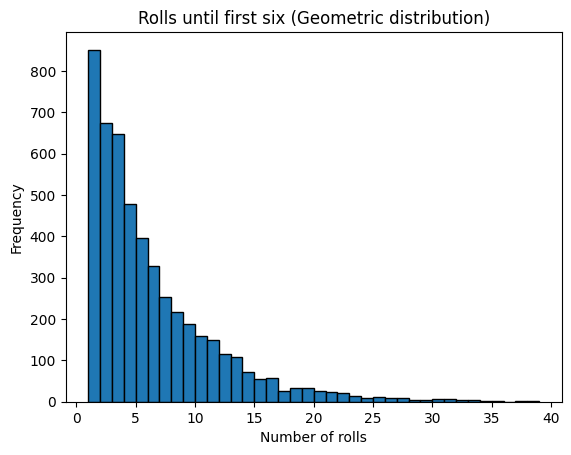

In [18]:
plt.hist(df["rolls_needed"], bins=range(1,40), edgecolor="black")
plt.title("Rolls until first six (Geometric distribution)")
plt.xlabel("Number of rolls")
plt.ylabel("Frequency")
plt.show()

You should see:

* very tall bar at 1
* rapidly decreasing probabilities
* long tail

## The cool property (very important intuition)

Suppose you already rolled 10 times and still no six.

What are your chances on the next roll?

Still **exactly the same** as always.

Past failures don't matter.

This is called the **memoryless property**.

Only geometric (and exponential in continuous time) behaves this way.

## Clean comparison (final map)

| Distribution      | Dice Question                    |
| ----------------- | -------------------------------- |
| Binomial          | How many sixes in 20 rolls?      |
| Poisson           | How many sixes in 1 minute?      |
| Negative Binomial | How many rolls to get 5 sixes?   |
| Geometric         | How many rolls to get first six? |

## One-sentence intuition

Geometric measures waiting for the first success.  
Negative binomial measures waiting for several successes.